In [1]:
import numpy as np
import pandas as pd
from plotnine import *
import argparse
import re
import sys
import gzip


parser = argparse.ArgumentParser()
parser.add_argument('--genes', '-g', help='genes bed file')
parser.add_argument('--depths', '-d', help='per gene read counts')
parser.add_argument('--megs', '-m', help='total bam read counts')
parser.add_argument('--readlength', '-l', help='read length',default=150)

args = parser.parse_args()
genes = args.genes
depths = args.depths
megs = args.megs
readlen = args.readlength




In [2]:
genefile = "./resources/VectorBase-59_AaegyptiLVP_AGWG_gene_regions_refseq.bed"
depthfile = "./all_gene_covs.txt.gz"
megfile = "./all_bam_mbs.txt.gz"
readlength = 150

In [3]:
depths = np.genfromtxt(depthfile,skip_header=1,dtype=int,delimiter='\t')
samples = gzip.open(depthfile,'r').readline().strip().split()
samples = [s.decode() for s in samples]

In [4]:
megs = np.recfromtxt(megfile,names=['sample','mapped','unmapped'])
mb = (megs['mapped'] * readlength) / 1e6
genes = np.recfromtxt(genefile,names=['chrom','start','end','name','score','strand'],encoding=None)
kb = (genes['end']-genes['start'])/1e3


/opt/miniconda3/lib/python3.9/site-packages/numpy/lib/npyio.py:2371: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.


In [5]:
rpk = depths.astype(int).transpose() / kb
rpkm = rpk.transpose() / mb

In [6]:
kbdp = pd.DataFrame(data={'kb': kb, 'meandp': np.mean(depths,1), 'meanrpk': np.mean(rpkm,1)})

In [7]:
rpkmtab = pd.DataFrame(data={'gene': genes['name'], 'kb': kb, 
                             'sdrpkm': np.std(rpkm,1), 
                             'meanrpkm': np.mean(rpkm,1)})

rpkmnorm = rpkm/np.mean(rpkm)
rpkmnormtab = pd.DataFrame(data={'gene': genes['name'], 'kb': kb, 
                                 'sdrpkm': np.std(rpkmnorm,1), 
                                 'meanrpkm': np.mean(rpkmnorm,1)})

In [47]:
#get gste / p450 target genes from table
targetgenes = pd.read_table("gste_p450_annotations.txt",delimiter="\t",dtype=None,encoding=None)
targetgenes['genename'] = [re.sub('\_.*|\ .*','',a) for a in targetgenes['blastp']]
targetgenenames =  [g for g in genes['name'] if g in targetgenes['geneid'].tolist()]


/opt/miniconda3/lib/python3.9/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 104 rows containing missing values.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 6 x 6 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_volcano.png
/opt/miniconda3/lib/python3.9/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 104 rows containing missing values.


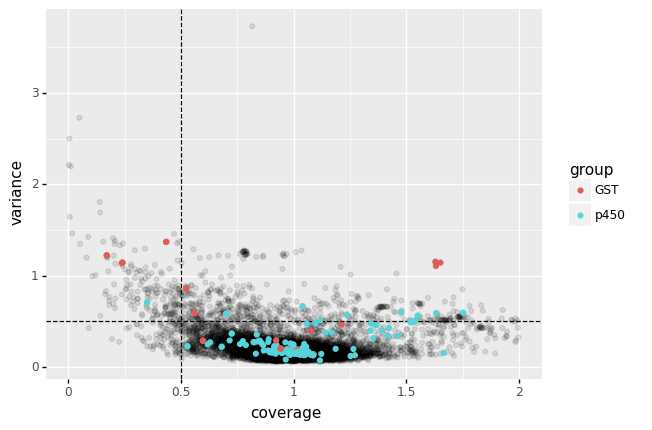

In [48]:
rpkmnormgstes = rpkmnormtab.merge(targetgenes,left_on="gene",right_on="geneid")
volcp = ggplot(rpkmnormtab, aes('meanrpkm', 'sdrpkm/meanrpkm'))  + \
    geom_hline(yintercept=0.5,linetype="dashed") + geom_vline(xintercept=0.5,linetype="dashed") +\
    geom_point(alpha=0.1) +\
    geom_point(data=rpkmnormgstes,mapping=aes(color="group")) +\
    xlim(0,2) + xlab("coverage") + ylab("variance")

volcp.draw()
volcp.save("rpkm_volcano.png",width=6,height=6)



In [58]:
#get genes with variance (sd/mean) > 0.5 

vargenes = rpkmnormtab['gene'][(rpkmnormtab['sdrpkm']/rpkmnormtab['meanrpkm']) > 0.5].tolist()

#vargenes = rpkmnormtab['gene'][np.logical_and((rpkmnormtab['sdrpkm']/rpkmnormtab['meanrpkm']) > 0.5,
#                                              (rpkmnormtab['meanrpkm'] > 0.25))]

vargenesgste = [v for v in vargenes if v in targetgenenames]
vargenesother = [v for v in vargenes if v not in targetgenenames]

In [59]:
len(vargenes),len(vargenesgste),len(vargenesother),

(754, 18, 736)

In [60]:
meta = pd.read_table("resources/meta_Aaeg1kg_spp.txt")


In [61]:
select = np.concatenate((vargenesgste, np.random.choice(vargenesother,10)))

selectidx = [g in select for g in genes['name'].tolist()]
#get target genes only from ndarray, make data frame
tgtrpkmnorm = pd.DataFrame(rpkmnorm[selectidx])
tgtrpkmnorm.index = select
tgtrpkmnorm.columns = samples
tgtrpkmnorm['gene'] = select
tgtrpkmnorm = pd.melt(tgtrpkmnorm,var_name="sample",id_vars=['gene'])
tgtrpkmnorm = tgtrpkmnorm.merge(meta)
tgtrpkmnorm = tgtrpkmnorm.merge(targetgenes,left_on='gene',right_on='geneid',how="outer")

In [62]:
#limit to big countries only
bigcountries = meta.groupby('country').filter(lambda x: len(x) >= 20)['country'].unique()

tgtrpkmnorm = tgtrpkmnorm.loc[[c in bigcountries for c in tgtrpkmnorm['country']]]
#sort by est demographic history
tgtrpkmnorm['country'] = pd.Categorical(tgtrpkmnorm['country'], ['Kenya', 'Uganda', 
                                                                 'Gabon', 'Ghana', 'BurkinaFaso','Senegal', 
                                                                 'PuertoRico', 'Trinidad', 
                                                                 'Brazil', 'USA', 
                                                                 'SaudiArabia', 'Vietnam','Philippines'])

In [63]:
tgtrpkmnorm_450 = tgtrpkmnorm[tgtrpkmnorm['group']=='p450']
tgtrpkmnorm_gst = tgtrpkmnorm[tgtrpkmnorm['group']=='GST']
tgtrpkmnorm_rnd = tgtrpkmnorm[tgtrpkmnorm['group'].isnull()]

In [80]:
print("c450",tgtrpkmnorm_450['gene'].unique())
print("c450",tgtrpkmnorm_450['genename'].unique())
print("GSTe",tgtrpkmnorm_gst['gene'].unique())
print("GSTe",tgtrpkmnorm_gst['genename'].unique())
print("GSTe",tgtrpkmnorm_gst['annotation'].unique())


c450 ['AAEL009117' 'AAEL001312' 'AAEL000326' 'AAEL006784' 'AAEL014614'
 'AAEL014619' 'AAEL014615' 'AAEL014613' 'AAEL014609' 'AAEL014603']
c450 ['CYP6M9' 'CYP9M6' 'CYP325S1' 'CYP9J17' 'CYP9J10' 'CYP9J22' 'CYP9J23'
 'CYP9J24' 'CYP9J26' 'CYP9J29']
GSTe ['AAEL015285' 'AAEL007962' 'AAEL007948' 'AAEL007951' 'AAEL007964'
 'AAEL007946' 'AAEL007947' 'AAEL010157']
GSTe ['AAEL015285-PB' 'AAEL015285-PA' 'GSTE4' 'GSTE7' 'GSTE2' 'GSTE5' 'GSTE6'
 'GSTE3' 'microsomal']
GSTe ['glutathione S-transferase T3 isoform X3'
 'glutathione S-transferase T3 isoform X4'
 'glutathione S-transferase T3 isoform X1'
 'glutathione S-transferase T3 isoform X2' 'glutathione S-transferase 1'
 'glutathione S-transferase 1-like'
 'microsomal glutathione S-transferase 1'
 'microsomal glutathione S-transferase 1-like']


In [68]:
ylim=[0,15]

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 10 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_p450_name_box.png


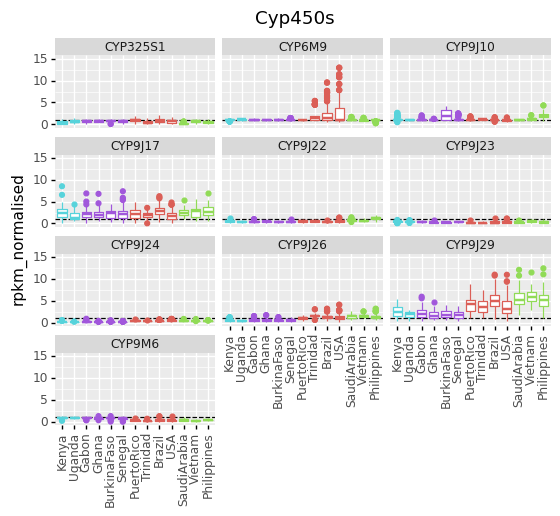

In [72]:
p450P = ggplot(tgtrpkmnorm_450, aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450P.draw()
p450P.save("rpkm_p450_name_box.png",width=15,height=10)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 10 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_gstes_name_box.png


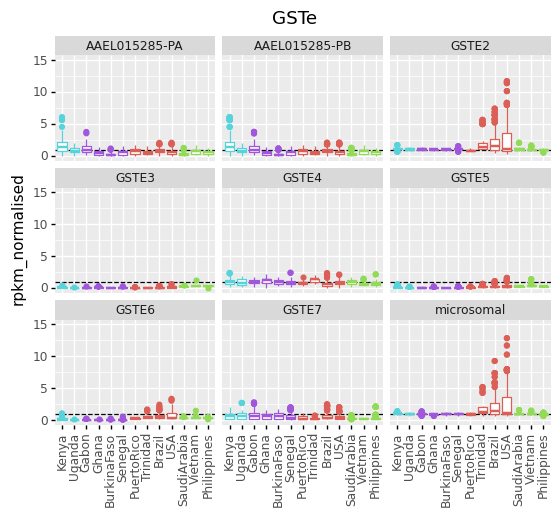

In [79]:
gstesP = ggplot(tgtrpkmnorm_gst, aes('country', 'value',color='contgroup',group='country')) +  \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("GSTe") +\
    coord_cartesian(ylim=ylim)
gstesP.draw()
gstesP.save("rpkm_gstes_name_box.png",width=15,height=10)


In [98]:
tgtrpkmnorm_gst[tgtrpkmnorm_gst['geneid'].isin(selects)]

,gene,sample,value,pop,spp,region,contgroup,country,annotation,blastp,geneid,group,genename
4536,AAEL007962,Cebu_City_Philippines-_1,0.251027,Cebu_City,AAA,Asia,Asia,Philippines,glutathione S-transferase 1,GSTE4_AAEL007962-PA (supercont1.291) [100%],AAEL007962,GST,GSTE4
4537,AAEL007962,Cebu_City_Philippines-_10,0.248405,Cebu_City,AAA,Asia,Asia,Philippines,glutathione S-transferase 1,GSTE4_AAEL007962-PA (supercont1.291) [100%],AAEL007962,GST,GSTE4
4538,AAEL007962,Cebu_City_Philippines-_11,0.248239,Cebu_City,AAA,Asia,Asia,Philippines,glutathione S-transferase 1,GSTE4_AAEL007962-PA (supercont1.291) [100%],AAEL007962,GST,GSTE4
4539,AAEL007962,Cebu_City_Philippines-_12,0.473897,Cebu_City,AAA,Asia,Asia,Philippines,glutathione S-transferase 1,GSTE4_AAEL007962-PA (supercont1.291) [100%],AAEL007962,GST,GSTE4
4540,AAEL007962,Cebu_City_Philippines-_13,0.728107,Cebu_City,AAA,Asia,Asia,Philippines,glutathione S-transferase 1,GSTE4_AAEL007962-PA (supercont1.291) [100%],AAEL007962,GST,GSTE4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16990,AAEL007964,Debug024_aegypti_Thies_Senegal_M_14,0.027460,Thies,AAF,West Africa,Wafrica,Senegal,glutathione S-transferase 1-like,GSTE5_AAEL007964-PA (supercont1.291) [100%],AAEL007964,GST,GSTE5
16991,AAEL007964,Debug024_aegypti_Thies_Senegal_M_14,0.027460,Thies,AAF,West Africa,Wafrica,Senegal,glutathione S-transferase 1,GSTE5_AAEL007964-PA (supercont1.291) [100%],AAEL007964,GST,GSTE5
16992,AAEL007964,Debug024_aegypti_Thies_Senegal_M_15,0.038762,Thies,AAF,West Africa,Wafrica,Senegal,glutathione S-transferase 1-like,GSTE5_AAEL007964-PA (supercont1.291) [100%],AAEL007964,GST,GSTE5
16993,AAEL007964,Debug024_aegypti_Thies_Senegal_M_15,0.038762,Thies,AAF,West Africa,Wafrica,Senegal,glutathione S-transferase 1-like,GSTE5_AAEL007964-PA (supercont1.291) [100%],AAEL007964,GST,GSTE5


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 4 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_gstes_select_name_box.png
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 4 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_p450_select_name_box.png


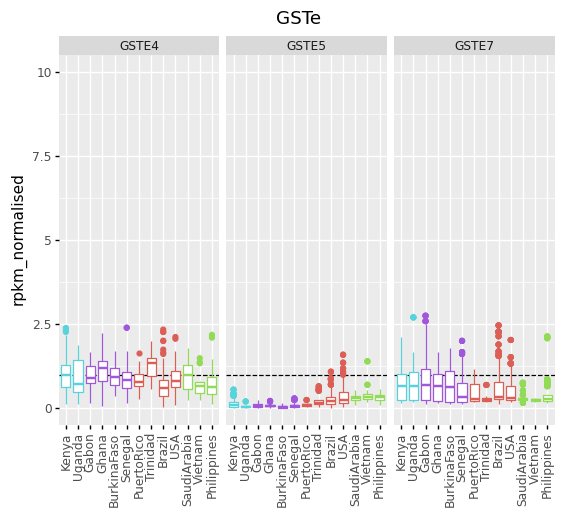

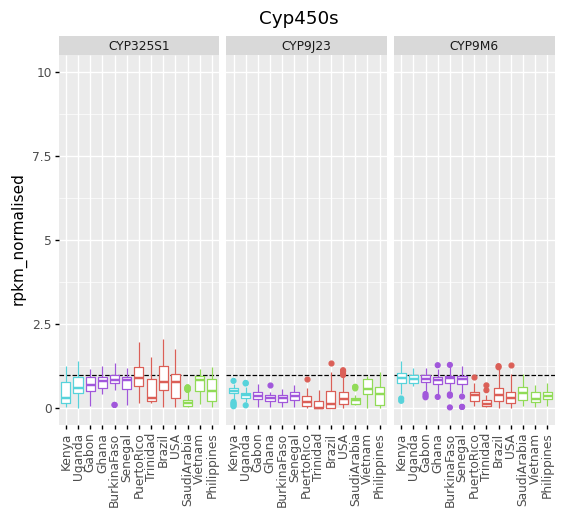

In [97]:
selects = ["AAEL000326", "AAEL001312", "AAEL014615",
           "AAEL007948","AAEL007964","AAEL007962",
          "AAEL005123","AAEL023980","AAEL022583"]

# AAEL000326 -> 3:112mb
# AAEL001312 -> 2:447mb

ylim=[0,10]
gstesPk = ggplot(tgtrpkmnorm_gst[tgtrpkmnorm_gst['geneid'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) +  \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("GSTe") +\
    coord_cartesian(ylim=ylim)
gstesPk.draw()
gstesPk.save("rpkm_gstes_select_name_box.png",width=15,height=4)

p450Pk = ggplot(tgtrpkmnorm_450[tgtrpkmnorm_450['geneid'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450Pk.draw()
p450Pk.save("rpkm_p450_select_name_box.png",width=15,height=4)


# rndPk = ggplot(tgtrpkmnorm_rnd[tgtrpkmnorm_rnd['gene'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) + \
#     geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
#     theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
#     ylab("rpkm_normalised") + ggtitle("random") +\
#     coord_cartesian(ylim=ylim)
# rndPk.draw()
# rndPk.save("rpkm_rnd_select_name_box.png",width=15,height=4)




In [91]:
p450Pk = ggplot(rpkmnormgstes[rpkmnormgstes['group']=="p450"], aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450Pk.draw()

PlotnineError: "Could not evaluate the 'color' mapping: 'contgroup' (original error: name 'contgroup' is not defined)"

In [105]:
pseudogenes = open("resources/pseudogene_ids.txt",'r').read().strip().split()


In [119]:
sum([g in pseudogenes for g in rpkmnormtab['gene']])

0

In [114]:
rpkmnormtab


,gene,kb,sdrpkm,meanrpkm
0,AAEL006377,1.204,0.159395,1.014874
1,AAEL020501,0.925,0.162446,0.971630
2,AAEL021898,0.892,0.202440,0.979970
3,AAEL022972,1.109,0.185112,0.976553
4,AAEL024582,0.610,0.195625,0.978098
...,...,...,...,...
13685,AAEL024090,20.623,0.213698,0.699210
13686,AAEL008177,91.774,0.056072,0.716906
13687,AAEL008185,26.773,0.294387,0.968530
13688,AAEL026824,55.924,0.163124,1.020217
